In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)


In [2]:
books = pd.DataFrame({
    "book_id": [1, 2, 3, 4],
    "title": ["The Silent Archive", "Neon Skies", "Echoes of Time", "Rust & Ink"],
    "author": ["A. Moore", "J. Carter", "L. Chen", "M. Alvarez"],
    "genre": ["Thriller", "Sci-Fi", "Historical", "Literary Fiction"],
    "format": ["ebook", "paperback", "hardcover", "ebook"],
    "publication_date": pd.to_datetime(["2022-03-10", "2023-06-18", "2021-09-05", "2024-01-20"])
})

books


,book_id,title,author,genre,format,publication_date
0,1,The Silent Archive,A. Moore,Thriller,ebook,2022-03-10
1,2,Neon Skies,J. Carter,Sci-Fi,paperback,2023-06-18
2,3,Echoes of Time,L. Chen,Historical,hardcover,2021-09-05
3,4,Rust & Ink,M. Alvarez,Literary Fiction,ebook,2024-01-20


In [3]:
sales = pd.DataFrame({
    "sale_id": range(1, 13),
    "book_id": [1,1,1,2,2,3,3,3,4,4,4,4],
    "platform": [
        "Amazon", "Amazon", "Apple Books",
        "Amazon", "Barnes & Noble",
        "Amazon", "Apple Books", "Barnes & Noble",
        "Amazon", "Amazon", "Apple Books", "Barnes & Noble"
    ],
    "sale_date": pd.to_datetime([
        "2024-01-01","2024-01-08","2024-01-15",
        "2024-02-01","2024-02-10",
        "2024-01-03","2024-01-17","2024-02-01",
        "2024-03-01","2024-03-10","2024-03-15","2024-03-20"
    ]),
    "units_sold": [120, 180, 60, 90, 40, 70, 30, 20, 200, 240, 90, 60],
    "gross_revenue": [480, 720, 210, 540, 240, 980, 420, 280, 800, 960, 360, 240]
})

sales


,sale_id,book_id,platform,sale_date,units_sold,gross_revenue
0,1,1,Amazon,2024-01-01,120,480
1,2,1,Amazon,2024-01-08,180,720
2,3,1,Apple Books,2024-01-15,60,210
3,4,2,Amazon,2024-02-01,90,540
4,5,2,Barnes & Noble,2024-02-10,40,240
5,6,3,Amazon,2024-01-03,70,980
6,7,3,Apple Books,2024-01-17,30,420
7,8,3,Barnes & Noble,2024-02-01,20,280
8,9,4,Amazon,2024-03-01,200,800
9,10,4,Amazon,2024-03-10,240,960


In [4]:
engagement = pd.DataFrame({
    "book_id": [1, 2, 4],
    "kenp_pages_read": [85000, 42000, 120000],
    "avg_completion_rate": [0.78, 0.65, 0.82]
})

engagement


,book_id,kenp_pages_read,avg_completion_rate
0,1,85000,0.78
1,2,42000,0.65
2,4,120000,0.82


In [5]:
marketing = pd.DataFrame({
    "campaign_id": [1,2,3,4],
    "book_id": [1,2,3,4],
    "platform": ["Amazon Ads", "Facebook Ads", "Amazon Ads", "Instagram Ads"],
    "ad_spend": [1200, 800, 600, 1000],
    "clicks": [4800, 3100, 2200, 3900],
    "conversions": [360, 180, 140, 420]
})

marketing


,campaign_id,book_id,platform,ad_spend,clicks,conversions
0,1,1,Amazon Ads,1200,4800,360
1,2,2,Facebook Ads,800,3100,180
2,3,3,Amazon Ads,600,2200,140
3,4,4,Instagram Ads,1000,3900,420


In [6]:
costs = pd.DataFrame({
    "book_id": [1,2,3,4],
    "editing_cost": [1500, 1200, 1800, 1400],
    "design_cost": [600, 500, 700, 650],
    "printing_cost": [0, 400, 1200, 0]
})

costs


,book_id,editing_cost,design_cost,printing_cost
0,1,1500,600,0
1,2,1200,500,400
2,3,1800,700,1200
3,4,1400,650,0


In [7]:
revenue_by_book = sales.groupby("book_id")["gross_revenue"].sum().reset_index()

profit = revenue_by_book.merge(costs, on="book_id")
profit["total_cost"] = (
    profit["editing_cost"] +
    profit["design_cost"] +
    profit["printing_cost"]
)

profit["net_profit"] = profit["gross_revenue"] - profit["total_cost"]

profit


,book_id,gross_revenue,editing_cost,design_cost,printing_cost,total_cost,net_profit
0,1,1410,1500,600,0,2100,-690
1,2,780,1200,500,400,2100,-1320
2,3,1680,1800,700,1200,3700,-2020
3,4,2360,1400,650,0,2050,310


In [8]:
marketing["conversion_rate"] = marketing["conversions"] / marketing["clicks"]
marketing["cost_per_conversion"] = marketing["ad_spend"] / marketing["conversions"]

marketing


,campaign_id,book_id,platform,ad_spend,clicks,conversions,conversion_rate,cost_per_conversion
0,1,1,Amazon Ads,1200,4800,360,0.075000,3.333333
1,2,2,Facebook Ads,800,3100,180,0.058065,4.444444
2,3,3,Amazon Ads,600,2200,140,0.063636,4.285714
3,4,4,Instagram Ads,1000,3900,420,0.107692,2.380952


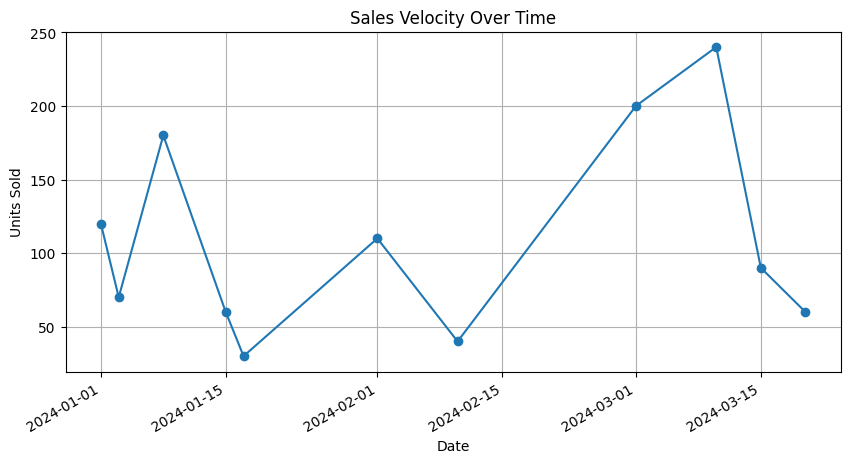

In [9]:
sales_trend = sales.groupby("sale_date")["units_sold"].sum()

sales_trend.plot(marker="o")
plt.title("Sales Velocity Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.grid(True)
plt.show()


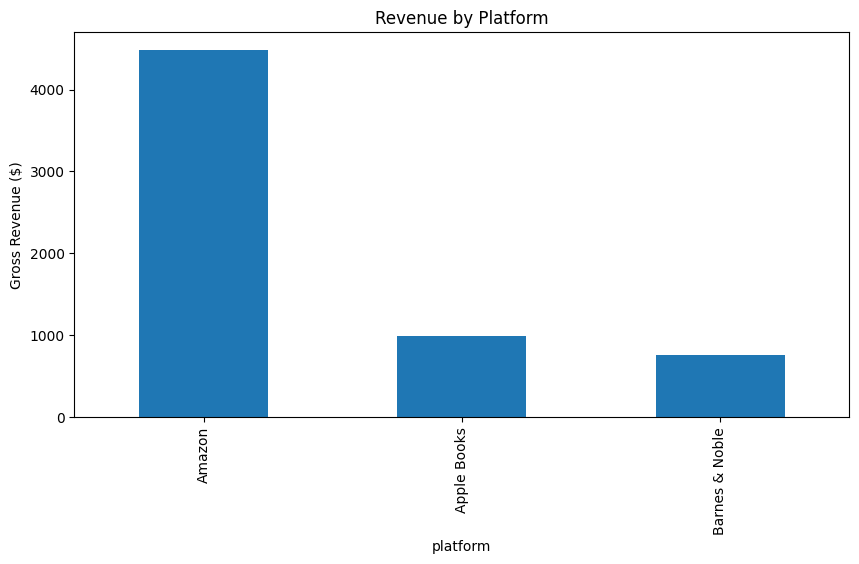

In [10]:
platform_perf = sales.groupby("platform")["gross_revenue"].sum()

platform_perf.plot(kind="bar")
plt.title("Revenue by Platform")
plt.ylabel("Gross Revenue ($)")
plt.show()
